# 03 — Modelagem

Compara sete classificadores do scikit-learn, mede de onde vem o poder preditivo, ajusta hiperparâmetros e escolhe o ponto de corte, tudo sem tocar no conjunto de teste.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, matthews_corrcoef, precision_score
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, StratifiedGroupKFold, StratifiedKFold,
    cross_val_predict, cross_validate,
)

from src.config import (
    CV_FOLDS, DATA_PROCESSED, GROUP, METRICS, MODELS, RANDOM_STATE, TARGET, TEST_FOLDS,  # semente fixa: 42
)
from src.data import load_processed
from src.evaluation import save_table, score, threshold_sweep
from src.models import get_models, make_pipeline
from src.preprocessing import CADASTRAIS, CATEGORICAS, HISTORICO
from src.viz import AZUL, CINZA, LARANJA, VERDE, save, set_style

set_style()
pd.set_option("display.max_columns", None)
print("RANDOM_STATE =", RANDOM_STATE)

RANDOM_STATE = 42


In [2]:
df = load_processed()
FEATURES = CADASTRAIS + CATEGORICAS + HISTORICO
print(f"Dataset: {df.shape[0]:,} contas | {len(FEATURES)} features | taxa de maus {df[TARGET].mean():.2%}")

Dataset: 27,638 contas | 30 features | taxa de maus 1.43%


## 1. Split treino/teste

O split é **estratificado** (mesma proporção de maus nos dois lados) e **agrupado por proponente**: todas as contas de uma mesma pessoa ficam do mesmo lado. Sem isso, o modelo seria testado em pessoas que já viu no treino.

In [3]:
divisor = StratifiedGroupKFold(n_splits=TEST_FOLDS, shuffle=True, random_state=RANDOM_STATE)
idx_treino, idx_teste = next(divisor.split(df, df[TARGET], df[GROUP]))
treino, teste = df.iloc[idx_treino].reset_index(drop=True), df.iloc[idx_teste].reset_index(drop=True)

X_train, y_train, g_train = treino[FEATURES], treino[TARGET], treino[GROUP]
assert not set(treino[GROUP]) & set(teste[GROUP]), "há proponentes nos dois conjuntos"

for nome, parte in [("Treino", treino), ("Teste", teste)]:
    print(f"{nome}: {len(parte):,} contas | {parte[GROUP].nunique():,} proponentes | "
          f"{int(parte[TARGET].sum())} maus ({parte[TARGET].mean():.2%})")
print("Proponentes em comum:", len(set(treino[GROUP]) & set(teste[GROUP])))

treino.to_csv(DATA_PROCESSED / "treino.csv", index=False)
teste.to_csv(DATA_PROCESSED / "teste.csv", index=False)

Treino: 21,994 contas | 6,878 proponentes | 300 maus (1.36%)
Teste: 5,644 contas | 1,737 proponentes | 94 maus (1.67%)
Proponentes em comum: 0


O treino fica com 21.994 contas de 6.878 proponentes (300 más, 1,36%) e o teste com 5.644 contas de 1.737 proponentes (94 más, 1,67%). Nenhum proponente aparece nos dois lados. As taxas não ficam idênticas porque contas de uma mesma pessoa não podem ser separadas para acertar a proporção.

O teste fica guardado até o notebook 04. Com 94 contas más, qualquer métrica medida nele terá margem de erro considerável, e por isso o notebook 04 reporta intervalo de confiança.

### Por que agrupar: o tamanho do vazamento

Medimos o mesmo modelo, nos mesmos dados de treino, com dois esquemas de validação cruzada: folds aleatórios (o padrão) e folds agrupados por proponente.

In [4]:
modelo_auditoria = get_models(FEATURES)["Random Forest"]
cv_aleatorio = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

auc_aleatorio = cross_validate(modelo_auditoria, X_train, y_train, cv=cv_aleatorio, scoring="roc_auc")["test_score"]
auc_agrupado = cross_validate(modelo_auditoria, X_train, y_train, cv=cv, groups=g_train, scoring="roc_auc")["test_score"]

auditoria = pd.DataFrame({
    "ROC-AUC médio": [auc_aleatorio.mean(), auc_agrupado.mean()],
    "desvio": [auc_aleatorio.std(), auc_agrupado.std()],
}, index=["Folds aleatórios (mesma pessoa em treino e validação)", "Folds agrupados por proponente"])
display(save_table(auditoria.round(4), "auditoria_vazamento"))

,ROC-AUC médio,desvio
Folds aleatórios (mesma pessoa em treino e validação),0.7810,0.0165
Folds agrupados por proponente,0.7413,0.0271


Com folds aleatórios o ROC-AUC é 0,781; com folds agrupados, 0,741. A diferença de 0,04 não é capacidade preditiva: é o modelo reconhecendo pessoas que já viu. Todos os resultados a partir daqui usam a validação agrupada, que responde à pergunta certa: como o modelo se sai com um proponente que nunca viu.

## 2. Modelos candidatos

Sete candidatos de famílias diferentes, todos nativos do scikit-learn e definidos em `src/models.py`. Cada um é um `Pipeline` completo: one-hot das categóricas, padronização quando o algoritmo precisa, e o classificador. Os modelos tratam o desbalanceamento com `class_weight="balanced"`, que dá aos maus pagadores peso proporcional à sua raridade.

In [5]:
modelos = get_models(FEATURES)
for nome, pipe in modelos.items():
    prep = pipe.named_steps["prep"].transformers[0][1]
    escala = "com padronização" if prep != "passthrough" else "sem padronização"
    print(f"{nome:26s} {type(pipe.named_steps['clf']).__name__:32s} {escala}")

Baseline (taxa média)      DummyClassifier                  sem padronização
Regressão Logística        LogisticRegression               com padronização
Naive Bayes Gaussiano      GaussianNB                       com padronização
Árvore de Decisão          DecisionTreeClassifier           sem padronização
Random Forest              RandomForestClassifier           sem padronização
Extra Trees                ExtraTreesClassifier             sem padronização
Gradient Boosting (Hist)   HistGradientBoostingClassifier   sem padronização


## 3. Validação cruzada

Cinco folds estratificados e agrupados por proponente, só no treino. O **ROC-AUC** e o **PR-AUC** medem a qualidade da ordenação de risco e não dependem de ponto de corte; MCC, F1, recall e precisão são calculados no corte padrão de 0,50.

In [6]:
scoring = {
    "roc_auc": "roc_auc", "pr_auc": "average_precision", "mcc": make_scorer(matthews_corrcoef),
    "f1": "f1", "recall": "recall", "precision": make_scorer(precision_score, zero_division=0),
    "accuracy": "accuracy",
}

linhas = {}
for nome, pipe in modelos.items():
    r = cross_validate(pipe, X_train, y_train, cv=cv, groups=g_train, scoring=scoring)
    linhas[nome] = {"ROC-AUC": r["test_roc_auc"].mean(), "ROC-AUC desvio": r["test_roc_auc"].std(),
                    "PR-AUC": r["test_pr_auc"].mean(), "MCC": r["test_mcc"].mean(), "F1": r["test_f1"].mean(),
                    "Recall": r["test_recall"].mean(), "Precisão": r["test_precision"].mean(),
                    "Acurácia": r["test_accuracy"].mean()}

comparacao = pd.DataFrame(linhas).T.sort_values("ROC-AUC", ascending=False).round(4)
display(save_table(comparacao, "comparacao_modelos"))

,ROC-AUC,ROC-AUC desvio,PR-AUC,MCC,F1,Recall,Precisão,Acurácia
Random Forest,0.7413,0.0271,0.0714,0.1113,0.1126,0.2378,0.0755,0.9485
Regressão Logística,0.7406,0.0081,0.1112,0.0813,0.0540,0.6141,0.0283,0.7026
Extra Trees,0.7303,0.0211,0.0482,0.0863,0.0740,0.3502,0.0415,0.8797
Gradient Boosting (Hist),0.7174,0.0284,0.0546,0.0761,0.0532,0.5731,0.0279,0.7182
Árvore de Decisão,0.7068,0.0513,0.0571,0.0812,0.0475,0.7717,0.0246,0.5735
Naive Bayes Gaussiano,0.6195,0.0481,0.0219,0.0183,0.0280,0.9710,0.0142,0.0831
Baseline (taxa média),0.5000,0.0000,0.0137,0.0000,0.0000,0.0000,0.0000,0.9863


## 4. Comparação

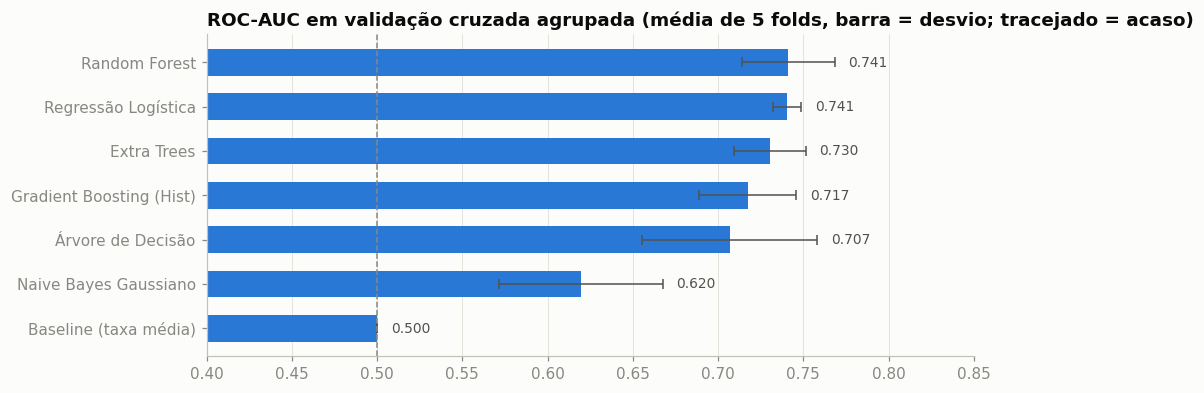

In [7]:
ordem = comparacao.sort_values("ROC-AUC")
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(ordem.index, ordem["ROC-AUC"], xerr=ordem["ROC-AUC desvio"], color=AZUL, height=0.6,
        error_kw={"ecolor": "#52514e", "elinewidth": 1, "capsize": 3})
for y, (v, d) in enumerate(zip(ordem["ROC-AUC"], ordem["ROC-AUC desvio"])):
    ax.text(v + d + 0.008, y, f"{v:.3f}", va="center", color="#52514e", fontsize=9)
ax.axvline(0.5, color=CINZA, linewidth=1, linestyle="--")
ax.set_xlim(0.4, 0.85)
ax.set_title("ROC-AUC em validação cruzada agrupada (média de 5 folds, barra = desvio; tracejado = acaso)")
ax.grid(axis="y", visible=False)
save(fig, "03_comparacao_modelos")
plt.show()

**Random Forest (0,741) e Regressão Logística (0,741) empatam na liderança**, seguidas por Extra Trees (0,730), Gradient Boosting (0,717) e Árvore de Decisão (0,707). As diferenças entre os quatro primeiros são menores que a variação entre folds (0,02 a 0,03), ou seja, estão dentro do ruído. Com 300 contas más no treino, não há dados para separar modelos tão próximos.

O que distingue os dois líderes:

- A Regressão Logística é a mais estável (desvio de 0,008 entre folds, contra 0,027 da Random Forest) e tem o melhor PR-AUC (0,111 contra 0,071), a métrica mais sensível à classe rara.
- O Naive Bayes fica bem atrás (0,620): ele supõe variáveis independentes, e as de histórico são fortemente relacionadas entre si.
- O baseline, que ignora as variáveis, tem ROC-AUC de 0,500 e **acurácia de 98,6%**, a maior da tabela. É a demonstração de que acurácia não mede nada aqui.

MCC, F1, recall e precisão nesta tabela usam o corte de 0,50, que não é adequado para modelos com `class_weight="balanced"` (o Naive Bayes, por exemplo, sinaliza quase todas as contas). Por isso a escolha do modelo usa o ROC-AUC, e o corte é tratado separadamente na seção 6.

### De onde vem o poder preditivo

Repetimos a validação com três conjuntos de variáveis: só o formulário, só o histórico interno, e os dois juntos.

,Random Forest,Regressão Logística
Só formulário,0.5615,0.5505
Só histórico interno,0.7241,0.7352
Formulário + histórico,0.7413,0.7406


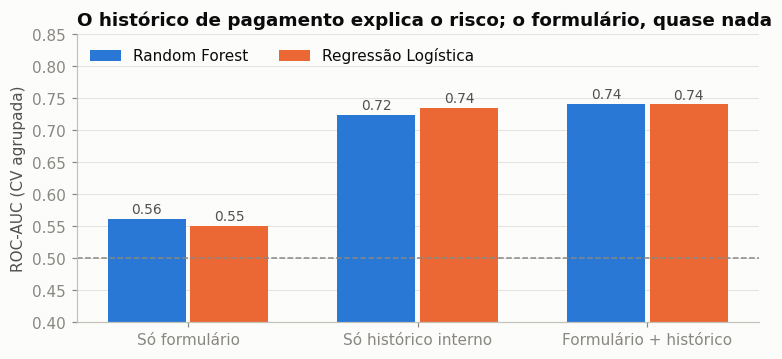

In [8]:
conjuntos = {"Só formulário": CADASTRAIS + CATEGORICAS, "Só histórico interno": HISTORICO, "Formulário + histórico": FEATURES}
linhas = {}
for nome_modelo in ["Regressão Logística", "Random Forest"]:
    for nome_conj, cols in conjuntos.items():
        pipe = get_models(cols)[nome_modelo]
        r = cross_validate(pipe, treino[cols], y_train, cv=cv, groups=g_train, scoring="roc_auc")["test_score"]
        linhas[(nome_modelo, nome_conj)] = r.mean()
ablacao = pd.Series(linhas).unstack(0).loc[list(conjuntos)].round(4)
display(save_table(ablacao, "ablacao_features"))

fig, ax = plt.subplots(figsize=(8, 3.4))
x = np.arange(len(ablacao))
for i, (col, cor) in enumerate(zip(ablacao.columns, [AZUL, LARANJA])):
    ax.bar(x + (i - 0.5) * 0.36, ablacao[col], width=0.34, color=cor, label=col)
    for xi, v in zip(x, ablacao[col]):
        ax.text(xi + (i - 0.5) * 0.36, v + 0.008, f"{v:.2f}", ha="center", color="#52514e", fontsize=9)
ax.axhline(0.5, color=CINZA, linewidth=1, linestyle="--")
ax.set_xticks(x, ablacao.index)
ax.set_ylim(0.4, 0.85)
ax.set_ylabel("ROC-AUC (CV agrupada)")
ax.set_title("O histórico de pagamento explica o risco; o formulário, quase nada")
ax.legend(loc="upper left", ncols=2)
ax.grid(axis="x", visible=False)
save(fig, "03_ablacao")
plt.show()

Só com o formulário, os dois modelos ficam em 0,55 a 0,56, pouco acima do acaso. Só com o histórico interno, chegam a 0,72 a 0,74. Juntar os dois acrescenta no máximo 0,02.

Essa é a principal conclusão técnica do projeto: **renda, idade, ocupação e estado civil quase não informam quem vai atrasar; o comportamento de pagamento anterior informa.** Confirma o que a EDA sugeria com as correlações próximas de zero.

## 5. Ajuste de hiperparâmetros

Ajustamos os dois melhores candidatos de famílias diferentes, com a mesma validação agrupada e o ROC-AUC como critério.

In [9]:
busca_lr = GridSearchCV(
    make_pipeline(LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE),
                  FEATURES, scale=True),
    {"clf__C": [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]},
    scoring="roc_auc", cv=cv,
).fit(X_train, y_train, groups=g_train)

busca_rf = RandomizedSearchCV(
    make_pipeline(RandomForestClassifier(class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1),
                  FEATURES),
    {"clf__n_estimators": [300, 500],
     "clf__max_depth": [4, 6, 8, 12, None],
     "clf__min_samples_leaf": [10, 20, 40, 80],
     "clf__max_features": ["sqrt", 0.3, 0.5]},
    n_iter=12, scoring="roc_auc", cv=cv, random_state=RANDOM_STATE,
).fit(X_train, y_train, groups=g_train)

buscas = {"Regressão Logística": busca_lr, "Random Forest": busca_rf}
tuning = pd.DataFrame({
    nome: {"ROC-AUC antes": comparacao.loc[nome, "ROC-AUC"], "ROC-AUC depois": b.best_score_,
           "desvio entre folds": b.cv_results_["std_test_score"][b.best_index_],
           "melhores parâmetros": {k.replace("clf__", ""): v for k, v in b.best_params_.items()}}
    for nome, b in buscas.items()
}).T
display(tuning)
save_table(tuning, "tuning")

NOME_CAMPEAO = max(buscas, key=lambda n: buscas[n].best_score_)
modelo_final = buscas[NOME_CAMPEAO].best_estimator_
print("Modelo escolhido:", NOME_CAMPEAO)

,ROC-AUC antes,ROC-AUC depois,desvio entre folds,melhores parâmetros
Regressão Logística,0.7406,0.748931,0.031301,{'C': 0.0003}
Random Forest,0.7413,0.747154,0.023512,"{'n_estimators': 300, 'min_samples_leaf': 40, ..."


Modelo escolhido: Regressão Logística


- **Regressão Logística:** de 0,741 para 0,749, com `C = 0,0003`, uma regularização forte.
- **Random Forest:** de 0,741 para 0,747, com árvores rasas (`max_depth = 4`, `min_samples_leaf = 40`).

Os dois ajustes apontam na mesma direção: modelos mais simples generalizam melhor. O sinal é concentrado em poucas variáveis e há poucas contas más para aprender padrões complexos. Os ganhos (menos de 0,01) são menores que a variação entre folds (0,02 a 0,03), então o ajuste confirma os modelos mais do que os melhora.

**Modelo escolhido: Regressão Logística.** A diferença de 0,002 para a Random Forest é um empate. Entre dois modelos de mesmo desempenho, fica o mais simples: cada variável tem um peso único e explicável, o que importa quando é preciso justificar uma recusa de crédito.

## 6. Ponto de corte

O modelo devolve uma probabilidade; a decisão exige um corte. Escolhemos o corte que maximiza o MCC usando previsões *out-of-fold* do treino: cada conta é pontuada por um modelo que não a viu, nem a outras contas do mesmo proponente. O conjunto de teste continua intocado.

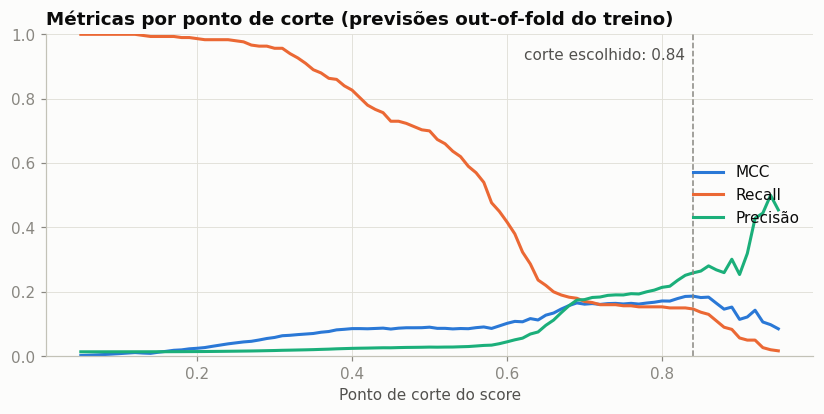

,roc_auc,pr_auc,mcc,f1,recall,precision,accuracy
"Corte 0,50",0.7532,0.0884,0.0901,0.0544,0.7000,0.0283,0.6679
Corte 0.84,0.7532,0.0884,0.1866,0.1872,0.1467,0.2588,0.9826


In [10]:
proba_oof = cross_val_predict(modelo_final, X_train, y_train, cv=cv, groups=g_train, method="predict_proba")[:, 1]
curva = threshold_sweep(y_train, proba_oof)
LIMIAR = float(curva.loc[curva["mcc"].idxmax(), "limiar"])

fig, ax = plt.subplots(figsize=(9, 3.8))
for col, cor, rotulo in [("mcc", AZUL, "MCC"), ("recall", LARANJA, "Recall"), ("precision", VERDE, "Precisão")]:
    ax.plot(curva["limiar"], curva[col], color=cor, label=rotulo)
ax.axvline(LIMIAR, color=CINZA, linewidth=1, linestyle="--")
ax.text(LIMIAR - 0.01, 0.92, f"corte escolhido: {LIMIAR:.2f}", color="#52514e", ha="right")
ax.set_xlabel("Ponto de corte do score")
ax.set_ylim(0, 1)
ax.set_title("Métricas por ponto de corte (previsões out-of-fold do treino)")
ax.legend(loc="center right")
save(fig, "03_limiar")
plt.show()

oof = pd.DataFrame({"Corte 0,50": score(y_train, proba_oof, 0.5), f"Corte {LIMIAR:.2f}": score(y_train, proba_oof, LIMIAR)}).T.round(4)
display(oof)

O corte que maximiza o MCC nas previsões *out-of-fold* é **0,84** (MCC de 0,187, contra 0,090 no corte de 0,50).

- No corte de 0,50 o modelo sinaliza um terço das contas: identifica 70% dos maus, mas só 2,8% dos sinalizados são de fato maus. Operacionalmente inviável.
- No corte de 0,84 ele sinaliza poucas contas, com precisão de 25,9% e recall de 14,7%: um ponto de operação conservador, que marca só os casos mais claros.
- O MCC forma um platô entre 0,70 e 0,86: o valor exato do corte importa pouco nessa região.

Uma observação sobre a escala: por causa do `class_weight="balanced"`, o número que o modelo devolve é um **score de risco**, não a probabilidade real de atraso. Um score de 0,84 não significa 84% de chance de calote; serve para ordenar e para cortar.

O ROC-AUC *out-of-fold* do modelo final é 0,753. O modelo é então treinado em todo o treino e salvo, junto com o corte, para o notebook 04.

In [11]:
modelo_final.fit(X_train, y_train)

MODELS.mkdir(parents=True, exist_ok=True)
joblib.dump({"modelo": modelo_final, "nome": NOME_CAMPEAO, "limiar": LIMIAR, "features": FEATURES},
            MODELS / "melhor_modelo.joblib")
METRICS.mkdir(parents=True, exist_ok=True)
(METRICS / "modelo_final.json").write_text(json.dumps({
    "modelo": NOME_CAMPEAO,
    "parametros": {k.replace("clf__", ""): v for k, v in buscas[NOME_CAMPEAO].best_params_.items()},
    "roc_auc_cv": round(float(buscas[NOME_CAMPEAO].best_score_), 4),
    "limiar": LIMIAR,
}, ensure_ascii=False, indent=2))
print(f"Modelo final ({NOME_CAMPEAO}) treinado em todo o treino e salvo em results/models/melhor_modelo.joblib")

Modelo final (Regressão Logística) treinado em todo o treino e salvo em results/models/melhor_modelo.joblib
